#### 1) Importing Necessary Libraries:

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as Imbpipeline

In [3]:
import warnings
warnings.filterwarnings('ignore')

#### 2) Laoding Data:

In [5]:
df = pd.read_csv('Telco-Customer-Churn.csv')

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [9]:
df.shape

(7032, 21)

In [11]:
df['Churn'].value_counts() / len(df) * 100

Churn
No     73.421502
Yes    26.578498
Name: count, dtype: float64

- We have a imbalanced Dataset here.
- We may need to use Over Sampling to get Model to learn more about Churned Customers.
- We have both Numeric and Categorical Data in Dataset.
- There are no missing values in dataset.

In [13]:
df['customerID'].nunique()

7032

- CustomerId is unique for each record, which won't help in Churn Prediction.

In [14]:
df.drop('customerID', axis= 1, inplace= True)

#### 3) Data Exploaration and Transformations:

In [15]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

##### 1) Checking Correlation of Features with Target Variable:

- As most of our features are of Object Datatype, we will have to convert those into numbers to calculate correlations.
- We will use LabelEncoder to convert all categorical features to numeric.

In [19]:
temp = df.copy() # Creating Copy of Dataframe to use LabelEncoder on

In [20]:
cat_cols = list(temp.select_dtypes(include= 'object').columns) # Storing names of Object type column in list.

le = LabelEncoder() #Label Encoder Instance

for col in cat_cols:
    temp[col] = le.fit_transform(df[col])

In [21]:
temp.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [23]:
# Correlation of Features with Target:

corr = temp.corr()

In [24]:
corr

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
gender,1.000000,-0.001819,-0.001379,0.010349,0.005285,-0.007515,-0.006908,-0.002236,-0.014899,-0.011920,0.001348,-0.006695,-0.005624,-0.008920,0.000095,-0.011902,0.016942,-0.013779,0.000048,-0.008545
SeniorCitizen,-0.001819,1.000000,0.016957,-0.210550,0.015683,0.008392,0.146287,-0.032160,-0.127937,-0.013355,-0.021124,-0.151007,0.031019,0.047088,-0.141820,0.156258,-0.038158,0.219874,0.102411,0.150541
Partner,-0.001379,0.016957,1.000000,0.452269,0.381912,0.018397,0.142717,0.000513,0.150610,0.153045,0.165614,0.126488,0.136679,0.129907,0.294094,-0.013957,-0.156232,0.097825,0.319072,-0.149982
Dependents,0.010349,-0.210550,0.452269,1.000000,0.163386,-0.001078,-0.024975,0.044030,0.151198,0.090231,0.079723,0.132530,0.046214,0.022088,0.240556,-0.110131,-0.041989,-0.112343,0.064653,-0.163128
tenure,0.005285,0.015683,0.381912,0.163386,1.000000,0.007877,0.343673,-0.029835,0.327283,0.372434,0.372669,0.324729,0.290572,0.296785,0.676734,0.004823,-0.370087,0.246862,0.825880,-0.354049
PhoneService,-0.007515,0.008392,0.018397,-0.001078,0.007877,1.000000,-0.020504,0.387266,-0.014163,0.024040,0.004718,-0.018136,0.056393,0.043025,0.003019,0.016696,-0.005499,0.248033,0.113008,0.011691
MultipleLines,-0.006908,0.146287,0.142717,-0.024975,0.343673,-0.020504,1.000000,-0.108849,0.007306,0.117276,0.122614,0.010941,0.175403,0.181705,0.111029,0.165306,-0.176598,0.433905,0.453202,0.038043
InternetService,-0.002236,-0.032160,0.000513,0.044030,-0.029835,0.387266,-0.108849,1.000000,-0.028003,0.036735,0.045558,-0.025626,0.108190,0.097967,0.099579,-0.138166,0.084504,-0.322173,-0.175691,-0.047097
OnlineSecurity,-0.014899,-0.127937,0.150610,0.151198,0.327283,-0.014163,0.007306,-0.028003,1.000000,0.184942,0.175789,0.284875,0.044399,0.056313,0.373980,-0.157723,-0.096593,-0.053576,0.254473,-0.289050
OnlineBackup,-0.011920,-0.013355,0.153045,0.090231,0.372434,0.024040,0.117276,0.036735,0.184942,1.000000,0.187646,0.195581,0.147085,0.137083,0.280617,-0.012697,-0.125534,0.119943,0.375556,-0.195290


In [25]:
corr['Churn']

gender             -0.008545
SeniorCitizen       0.150541
Partner            -0.149982
Dependents         -0.163128
tenure             -0.354049
PhoneService        0.011691
MultipleLines       0.038043
InternetService    -0.047097
OnlineSecurity     -0.289050
OnlineBackup       -0.195290
DeviceProtection   -0.177883
TechSupport        -0.282232
StreamingTV        -0.036303
StreamingMovies    -0.038802
Contract           -0.396150
PaperlessBilling    0.191454
PaymentMethod       0.107852
MonthlyCharges      0.192858
TotalCharges       -0.199484
Churn               1.000000
Name: Churn, dtype: float64

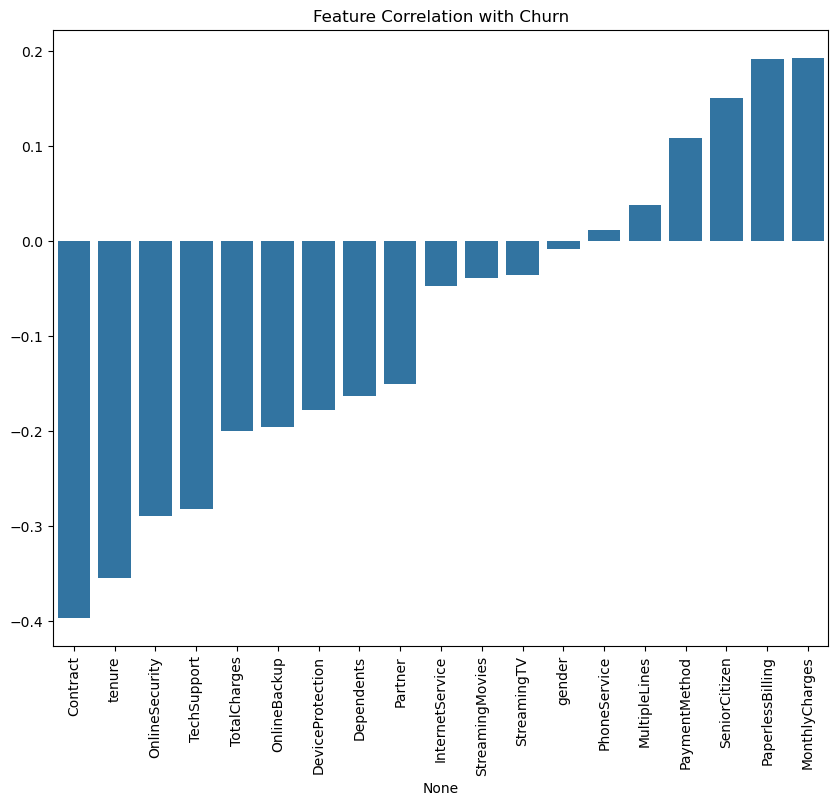

In [26]:
# Plotting Correlations of Features with Churn:

plt.figure(figsize= (10,8))
sns.barplot(x= corr['Churn'].sort_values().iloc[:-1].index, y= corr['Churn'].sort_values().iloc[:-1].values)
plt.title("Feature Correlation with Churn")
plt.xticks(rotation= 90)
plt.show()

##### 2) gender:

In [27]:
df['gender']

0       Female
1         Male
2         Male
3         Male
4       Female
         ...  
7027      Male
7028    Female
7029    Female
7030      Male
7031      Male
Name: gender, Length: 7032, dtype: object

In [28]:
df['gender'].value_counts()

gender
Male      3549
Female    3483
Name: count, dtype: int64

- Preprocessing:
    - One Hot Encoding.

In [31]:
gender_pipe = Imbpipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 3) SeniorCitizen:

In [33]:
df['SeniorCitizen']

0       0
1       0
2       0
3       0
4       0
       ..
7027    0
7028    0
7029    0
7030    1
7031    0
Name: SeniorCitizen, Length: 7032, dtype: int64

In [34]:
df['SeniorCitizen'].value_counts()

SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64

- No Preprocessing needed.

##### 4) Partner:

In [36]:
df['Partner']

0       Yes
1        No
2        No
3        No
4        No
       ... 
7027    Yes
7028    Yes
7029    Yes
7030    Yes
7031     No
Name: Partner, Length: 7032, dtype: object

In [37]:
df['Partner'].value_counts()

Partner
No     3639
Yes    3393
Name: count, dtype: int64

- Preprocessing:
    - One Hot Encoding

In [38]:
partner_pipe = Imbpipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 5) Dependents:

In [40]:
df['Dependents']

0        No
1        No
2        No
3        No
4        No
       ... 
7027    Yes
7028    Yes
7029    Yes
7030     No
7031     No
Name: Dependents, Length: 7032, dtype: object

In [41]:
df['Dependents'].value_counts()

Dependents
No     4933
Yes    2099
Name: count, dtype: int64

- Preprocessing:
    - One Hot Encoding.

In [42]:
dependent_pipe = Imbpipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 6) tenure:

In [44]:
df['tenure']

0        1
1       34
2        2
3       45
4        2
        ..
7027    24
7028    72
7029    11
7030     4
7031    66
Name: tenure, Length: 7032, dtype: int64

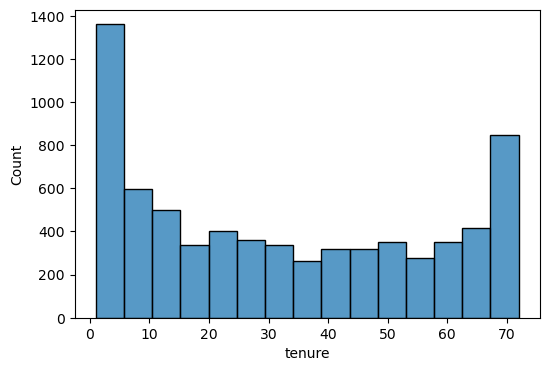

In [46]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'tenure')
plt.show()

- Preprocessing:
    - Scaling

In [53]:
tenure_pipe = Imbpipeline([
    ('sclare', StandardScaler())
])

##### 7) PhoneService:

In [55]:
df['PhoneService']

0        No
1       Yes
2       Yes
3        No
4       Yes
       ... 
7027    Yes
7028    Yes
7029     No
7030    Yes
7031    Yes
Name: PhoneService, Length: 7032, dtype: object

In [56]:
df['PhoneService'].value_counts()

PhoneService
Yes    6352
No      680
Name: count, dtype: int64

- Preprocessing:
    - One Hot Encoding

In [57]:
phservice_pipe = Imbpipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 8) MultipleLines:

In [60]:
df['MultipleLines']

0       No phone service
1                     No
2                     No
3       No phone service
4                     No
              ...       
7027                 Yes
7028                 Yes
7029    No phone service
7030                 Yes
7031                  No
Name: MultipleLines, Length: 7032, dtype: object

In [62]:
df['MultipleLines'].value_counts()

MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

- Preprocessing:
    - One Hot Encoding

In [63]:
multilines_pipe = Imbpipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 9) InternetService:

In [66]:
df['InternetService']

0               DSL
1               DSL
2               DSL
3               DSL
4       Fiber optic
           ...     
7027            DSL
7028    Fiber optic
7029            DSL
7030    Fiber optic
7031    Fiber optic
Name: InternetService, Length: 7032, dtype: object

In [67]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

- Preprocessing:
    - One Hot Encoding

In [68]:
internetser_pipe = Imbpipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 10) OnlineSecurity:

In [71]:
df['OnlineSecurity']

0        No
1       Yes
2       Yes
3       Yes
4        No
       ... 
7027    Yes
7028     No
7029    Yes
7030     No
7031    Yes
Name: OnlineSecurity, Length: 7032, dtype: object

In [72]:
df['OnlineSecurity'].value_counts()

OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

- Preprocessing:
    - One Hot Encoding

In [73]:
onlinesec_pipe = Imbpipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 11) OnlineBackup:

In [75]:
df['OnlineBackup']

0       Yes
1        No
2       Yes
3        No
4        No
       ... 
7027     No
7028    Yes
7029     No
7030     No
7031     No
Name: OnlineBackup, Length: 7032, dtype: object

In [76]:
df['OnlineBackup'].value_counts()

OnlineBackup
No                     3087
Yes                    2425
No internet service    1520
Name: count, dtype: int64

- Preprocessing:
    - One Hot Encoding

In [77]:
onlineback_pipe = Imbpipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])